# 5G 用户预测 —— 人工智能小组作业

**课程**：人工智能 | **系别**：软件工程系  
**提交日期**：第16周（6.15）随堂提交  

---

## 任务说明
根据用户基本信息和通信相关数据（话费信息、流量、活跃行为、套餐类型、区域信息等），预测用户是否为 5G 用户（二分类问题）。评估指标为 **AUC**。

## 算法方案
1. **逻辑回归（Logistic Regression）** —— 线性基线模型
2. **随机森林（Random Forest）** —— 集成树模型
3. **XGBoost（极端梯度提升）** —— 强力集成模型（对比基线）
4. **LightGBM** —— 高效梯度提升（最终提交模型）

## 1. 导入依赖库

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# 尝试导入高级库（如未安装可跳过）
try:
    import xgboost as xgb
    HAS_XGB = True
    print('XGBoost 已加载')
except ImportError:
    HAS_XGB = False
    print('XGBoost 未安装，将跳过')

try:
    import lightgbm as lgb
    HAS_LGB = True
    print('LightGBM 已加载')
except ImportError:
    HAS_LGB = False
    print('LightGBM 未安装，将跳过')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('\n所有依赖库加载完成！')

XGBoost 未安装，将跳过
LightGBM 未安装，将跳过

所有依赖库加载完成！


## 2. 数据加载

> **说明**：数据文件 `train.csv` 由老师上传至云平台，下载后放置于本文件同级目录。  
> 若暂无真实数据，下方代码块会自动生成结构相同的**模拟数据**用于演示。

In [3]:
import os

DATA_PATH = 'train.csv'

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f'✅ 已加载真实数据: {df.shape}')
else:
    print('⚠️  未找到 train.csv，使用模拟数据演示...')
    # =============================================
    # 生成模拟数据（与真实数据结构一致）
    # 60 个字段：id + cat_0~cat_19 + num_0~num_37 + target
    # =============================================
    np.random.seed(42)
    N = 50000  # 样本数
    
    data = {'id': range(N)}
    
    # 离散型特征（模拟套餐类型、城市等级、运营商区域等）
    cat_configs = [
        (3,), (5,), (2,), (4,), (6,),   # cat_0~4
        (3,), (8,), (2,), (3,), (5,),   # cat_5~9
        (4,), (2,), (7,), (3,), (4,),   # cat_10~14
        (2,), (6,), (3,), (5,), (2,),   # cat_15~19
    ]
    for i, (n_cat,) in enumerate(cat_configs):
        data[f'cat_{i}'] = np.random.randint(0, n_cat, N).astype(str)
    
    # 数值型特征（模拟话费、流量、通话时长等）
    num_configs = [
        (0, 500),    # 月均话费
        (0, 100),    # 月均流量(GB)
        (0, 1000),   # 月均通话分钟数
        (0, 200),    # 月均短信数
        (0, 50),     # 套餐月租
    ] + [(0, 1)] * 10 + [(0, 100)] * 23  # 其余标准化特征
    for i, (lo, hi) in enumerate(num_configs[:38]):
        data[f'num_{i}'] = np.random.uniform(lo, hi, N)
    
    # 生成有意义的 target（模拟高消费、高流量用户更可能是5G用户）
    score = (
        0.3 * (data['num_0'] / 500) +
        0.3 * (data['num_1'] / 100) +
        0.1 * (data['num_2'] / 1000) +
        0.1 * (np.array(data['cat_0']) == '2').astype(float) +
        0.2 * np.random.random(N)
    )
    data['target'] = (score > 0.45).astype(int)
    
    df = pd.DataFrame(data)
    print(f'✅ 模拟数据已生成: {df.shape}')

print(f'\n数据集形状: {df.shape}')
print(f'目标变量分布:\n{df["target"].value_counts()}')
print(f'\n正样本比例: {df["target"].mean():.2%}')

✅ 已加载真实数据: (800000, 60)

数据集形状: (800000, 60)
目标变量分布:
target
0.0    789400
1.0     10600
Name: count, dtype: int64

正样本比例: 1.32%


## 3. 探索性数据分析（EDA）

In [4]:
print('=== 数据基本信息 ===')
print(f'样本数量: {len(df):,}')
print(f'特征数量: {df.shape[1]}')
print(f'\n前5行:')
df.head()

=== 数据基本信息 ===
样本数量: 800,000
特征数量: 60

前5行:


,id,cat_0,cat_1,cat_2,cat_3,cat_4,cat_5,cat_6,cat_7,cat_8,...,num_29,num_30,num_31,num_32,num_33,num_34,num_35,num_36,num_37,target
0,0,2,103,9,4,3,1,3,4,4,...,2.000000,3.0,0.000000,0.0,0.0,0.0,0.0,0.089758,0.000129,0.0
1,1,0,177,6,2,2,1,2,4,4,...,0.968742,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000312,0.0
2,2,7,70,7,4,5,0,3,4,4,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000164,0.0
3,3,11,166,7,2,3,1,1,1,2,...,0.021729,0.0,0.021729,0.0,0.0,0.0,0.0,0.000081,0.000205,0.0
4,4,0,178,10,4,3,0,4,4,4,...,30.000000,30.0,0.000000,0.0,0.0,0.0,0.0,6127.621124,0.000298,0.0


In [5]:
# 缺失值统计
missing = df.isnull().sum()
missing_rate = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'缺失数量': missing, '缺失率(%)': missing_rate})
missing_with_data = missing_df[missing_df['缺失数量'] > 0]

if len(missing_with_data) > 0:
    print('存在缺失值的字段:')
    print(missing_with_data)
else:
    print('✅ 数据无缺失值')

✅ 数据无缺失值


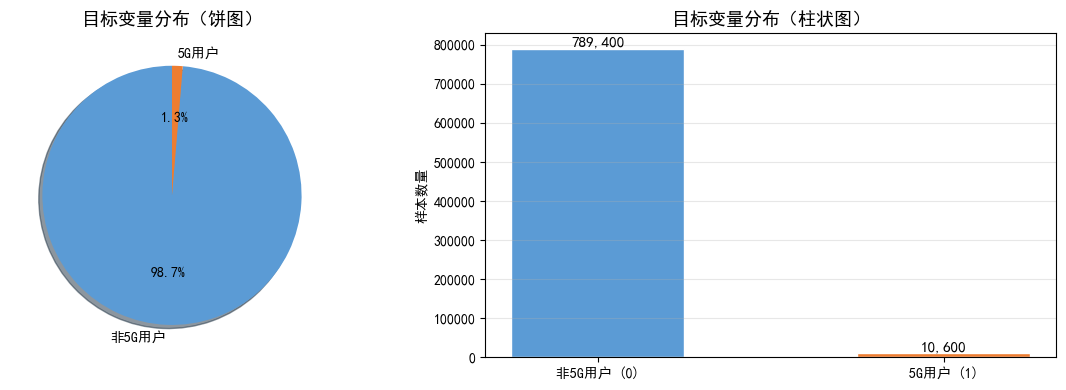

图表已保存为 target_distribution.png


In [6]:
# 目标变量分布可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 饼图
target_counts = df['target'].value_counts()
axes[0].pie(
    target_counts.values,
    labels=['非5G用户', '5G用户'],
    autopct='%1.1f%%',
    colors=['#5B9BD5', '#ED7D31'],
    startangle=90,
    shadow=True
)
axes[0].set_title('目标变量分布（饼图）', fontsize=13, fontweight='bold')

# 柱状图
bars = axes[1].bar(['非5G用户 (0)', '5G用户 (1)'], target_counts.values,
                   color=['#5B9BD5', '#ED7D31'], width=0.5, edgecolor='white')
for bar, val in zip(bars, target_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=11)
axes[1].set_title('目标变量分布（柱状图）', fontsize=13, fontweight='bold')
axes[1].set_ylabel('样本数量')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('图表已保存为 target_distribution.png')

In [7]:
# 数值型特征统计描述
num_cols = [c for c in df.columns if c.startswith('num_')]
cat_cols = [c for c in df.columns if c.startswith('cat_')]

print(f'数值型特征数: {len(num_cols)}')
print(f'离散型特征数: {len(cat_cols)}')
print('\n数值型特征统计摘要（前5个）:')
df[num_cols[:5]].describe().round(2)

数值型特征数: 38
离散型特征数: 20

数值型特征统计摘要（前5个）:


,num_0,num_1,num_2,num_3,num_4
count,800000.00,800000.00,800000.00,800000.00,800000.00
mean,50.74,1.02,8.84,92.12,609.80
std,43.55,1.32,2.29,56.62,865.90
min,1.00,0.00,0.00,50.00,0.00
25%,21.00,0.22,8.27,59.95,350.00
50%,33.00,0.61,9.50,75.05,490.00
75%,74.00,1.33,10.27,101.14,700.00
max,291.00,200.84,13.50,8104.10,331614.67


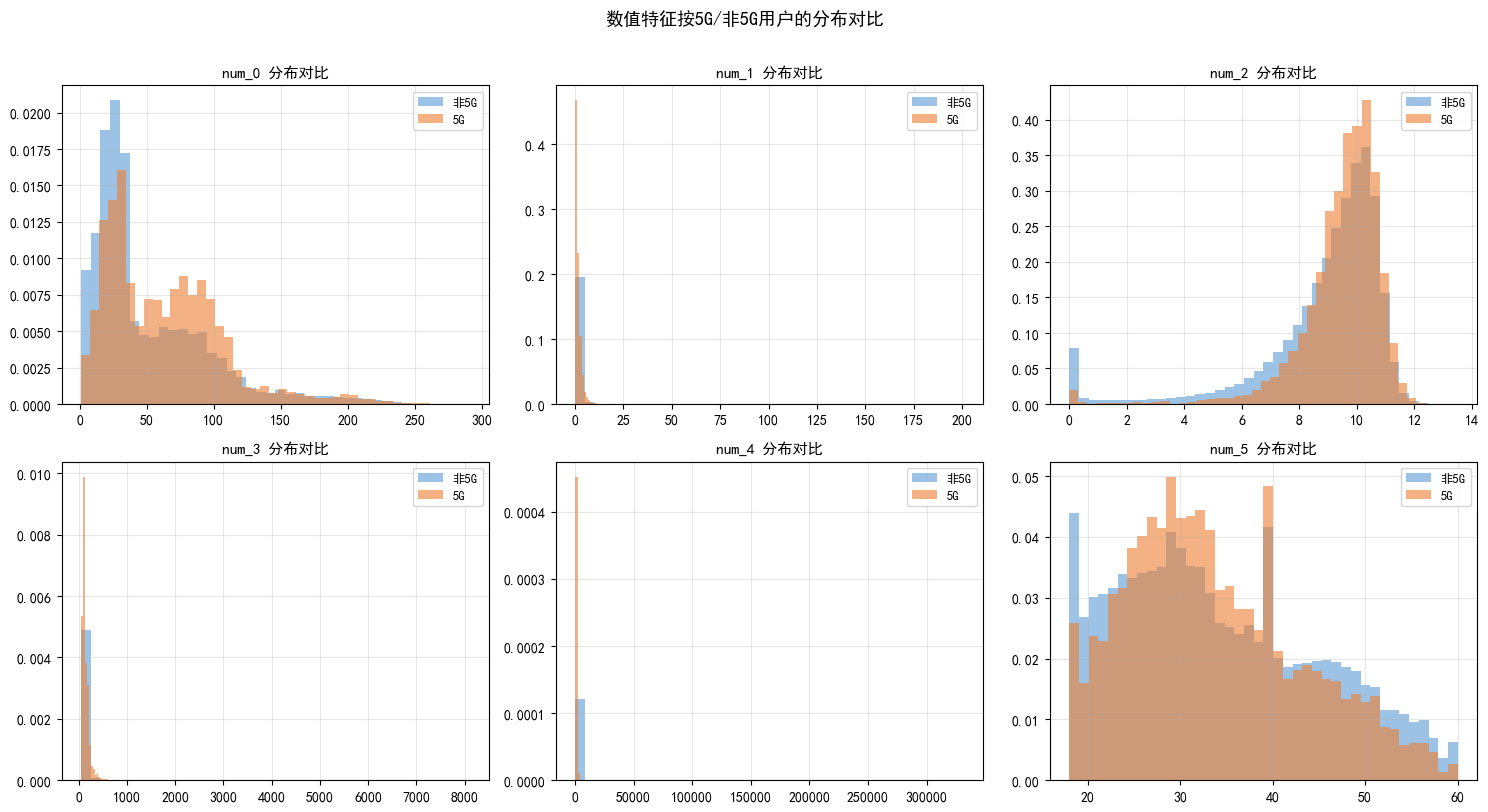

In [8]:
# 数值型特征与目标变量的关系（核密度图）
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols[:6]):
    for label, color, name in [(0, '#5B9BD5', '非5G'), (1, '#ED7D31', '5G')]:
        subset = df[df['target'] == label][col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
    axes[i].set_title(f'{col} 分布对比', fontsize=11)
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle('数值特征按5G/非5G用户的分布对比', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 数据预处理与特征工程

In [9]:
# 分离特征和目标变量
X = df.drop(columns=['id', 'target'])
y = df['target']

# 对离散型特征进行 Label Encoding
le = LabelEncoder()
for col in cat_cols:
    if col in X.columns:
        X[col] = le.fit_transform(X[col].astype(str))

print('特征编码完成')
print(f'特征维度: {X.shape}')

# 处理缺失值（若有）
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 划分训练集和验证集（8:2，分层采样保持类别比例）
X_train, X_val, y_train, y_val = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\n训练集: {X_train.shape}, 验证集: {X_val.shape}')
print(f'训练集正样本比例: {y_train.mean():.2%}')
print(f'验证集正样本比例: {y_val.mean():.2%}')

特征编码完成
特征维度: (800000, 58)

训练集: (640000, 58), 验证集: (160000, 58)
训练集正样本比例: 1.32%
验证集正样本比例: 1.32%


In [10]:
# 标准化（仅逻辑回归需要）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
print('特征标准化完成（供逻辑回归使用）')

特征标准化完成（供逻辑回归使用）


## 5. 模型训练与评估

### 5.1 模型一：逻辑回归（Logistic Regression）

**原理**：逻辑回归是一种广义线性模型，通过 Sigmoid 函数将线性组合映射到 (0,1) 区间，输出为正类的概率。适合处理二分类问题，可解释性强，作为基线模型。

In [11]:
print('=' * 50)
print('模型一：逻辑回归 (Logistic Regression)')
print('=' * 50)

lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train_scaled, y_train)

# 在验证集上评估
lr_prob = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_auc = roc_auc_score(y_val, lr_prob)

# 5折交叉验证
cv_scores_lr = cross_val_score(
    LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    X_train_scaled, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

print(f'验证集 AUC: {lr_auc:.4f}')
print(f'5折交叉验证 AUC: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')
print('\n分类报告:')
lr_pred = lr_model.predict(X_val_scaled)
print(classification_report(y_val, lr_pred, target_names=['非5G用户', '5G用户']))

模型一：逻辑回归 (Logistic Regression)
验证集 AUC: 0.8287
5折交叉验证 AUC: 0.8322 ± 0.0035

分类报告:
              precision    recall  f1-score   support

       非5G用户       0.99      1.00      0.99    157880
        5G用户       0.00      0.00      0.00      2120

    accuracy                           0.99    160000
   macro avg       0.49      0.50      0.50    160000
weighted avg       0.97      0.99      0.98    160000



### 5.2 模型二：随机森林（Random Forest）

**原理**：随机森林是 Bagging 集成学习方法，通过构建多棵决策树并进行投票来降低方差、提高泛化能力。每棵树在随机子集数据和特征上训练，减少过拟合，对高维特征数据效果好，且能提供特征重要性排序。

In [12]:
print('=' * 50)
print('模型二：随机森林 (Random Forest)')
print('=' * 50)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

rf_prob = rf_model.predict_proba(X_val)[:, 1]
rf_auc = roc_auc_score(y_val, rf_prob)

cv_scores_rf = cross_val_score(
    RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1),
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

print(f'验证集 AUC: {rf_auc:.4f}')
print(f'5折交叉验证 AUC: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')
print('\n分类报告:')
rf_pred = rf_model.predict(X_val)
print(classification_report(y_val, rf_pred, target_names=['非5G用户', '5G用户']))

模型二：随机森林 (Random Forest)


TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

Detailed tracebacks of the workers should have been printed to stderr in the executor process if faulthandler was not disabled.

In [ ]:
# 特征重要性可视化（Top 20）
feature_importance = pd.DataFrame({
    '特征': X_train.columns,
    '重要性': rf_model.feature_importances_
}).sort_values('重要性', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(feature_importance['特征'][::-1], feature_importance['重要性'][::-1],
               color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, 20)))
ax.set_title('随机森林特征重要性（Top 20）', fontsize=13, fontweight='bold')
ax.set_xlabel('特征重要性分数')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 模型三：XGBoost（可选）

**原理**：XGBoost 是基于 GBDT（梯度提升决策树）的高效实现，通过迭代方式添加弱分类器（残差树），每棵树拟合前一棵树的负梯度，同时引入二阶导数、正则化项和列采样等技术，在防止过拟合的同时达到更高精度。

In [ ]:
if HAS_XGB:
    print('=' * 50)
    print('模型三：XGBoost')
    print('=' * 50)
    
    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    xgb_model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        eval_metric='auc',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    xgb_prob = xgb_model.predict_proba(X_val)[:, 1]
    xgb_auc = roc_auc_score(y_val, xgb_prob)
    print(f'验证集 AUC: {xgb_auc:.4f}')
    print('\n分类报告:')
    xgb_pred = xgb_model.predict(X_val)
    print(classification_report(y_val, xgb_pred, target_names=['非5G用户', '5G用户']))
else:
    print('XGBoost 未安装，跳过此模型。')
    print('安装命令: pip install xgboost')
    xgb_auc = None

### 5.4 模型四：LightGBM（可选）

**原理**：LightGBM 是微软开发的高效梯度提升框架，采用**直方图算法**加速特征分裂，**Leaf-wise（按叶分裂）**策略而非 Level-wise，在精度相当的情况下速度更快、内存更小。适合大规模数据和高维特征。

In [ ]:
if HAS_LGB:
    print('=' * 50)
    print('模型四：LightGBM')
    print('=' * 50)
    
    lgb_model = lgb.LGBMClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        is_unbalance=True,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    
    lgb_prob = lgb_model.predict_proba(X_val)[:, 1]
    lgb_auc = roc_auc_score(y_val, lgb_prob)
    print(f'验证集 AUC: {lgb_auc:.4f}')
    print('\n分类报告:')
    lgb_pred = lgb_model.predict(X_val)
    print(classification_report(y_val, lgb_pred, target_names=['非5G用户', '5G用户']))
else:
    print('LightGBM 未安装，跳过此模型。')
    print('安装命令: pip install lightgbm')
    lgb_auc = None

## 6. 模型对比与可视化

In [ ]:
# ROC 曲线对比
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 左图：ROC 曲线 ---
ax = axes[0]
models_for_roc = [
    ('逻辑回归', lr_prob, lr_auc, '#5B9BD5'),
    ('随机森林', rf_prob, rf_auc, '#ED7D31'),
]
if HAS_XGB and xgb_auc:
    models_for_roc.append(('XGBoost', xgb_prob, xgb_auc, '#70AD47'))
if HAS_LGB and lgb_auc:
    models_for_roc.append(('LightGBM', lgb_prob, lgb_auc, '#7030A0'))

for name, prob, auc, color in models_for_roc:
    fpr, tpr, _ = roc_curve(y_val, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='随机猜测 (AUC=0.5)', linewidth=1)
ax.set_xlabel('假正率 (FPR)', fontsize=11)
ax.set_ylabel('真正率 (TPR)', fontsize=11)
ax.set_title('ROC 曲线对比', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# --- 右图：AUC 柱状图对比 ---
ax2 = axes[1]
model_names = [m[0] for m in models_for_roc]
auc_values = [m[2] for m in models_for_roc]
colors = [m[3] for m in models_for_roc]

bars = ax2.bar(model_names, auc_values, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, auc_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_ylim(0.5, 1.05)
ax2.set_title('各模型 AUC 对比', fontsize=13, fontweight='bold')
ax2.set_ylabel('AUC 分数')
ax2.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='AUC=0.9 参考线')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('对比图已保存为 model_comparison.png')

In [ ]:
# 汇总对比表格
results = pd.DataFrame([
    {'模型': name, 'AUC': f'{auc:.4f}', '适用场景': desc}
    for name, _, auc, _ in models_for_roc
    for desc in [{
        '逻辑回归': '快速基线、可解释性要求高',
        '随机森林': '中等规模、特征重要性分析',
        'XGBoost': '高精度、竞赛场景',
        'LightGBM': '大规模数据、高效训练'
    }.get(name, '-')]
])

print('\n=== 模型性能汇总 ===')
print(results.to_string(index=False))

# 找最优模型
best_idx = np.argmax([float(r) for r in results['AUC']])
print(f'\n🏆 最优模型: {results.iloc[best_idx]["模型"]} (AUC = {results.iloc[best_idx]["AUC"]})')

## 7. 评估函数（参考作业要求）

In [ ]:
# 作业要求中的评估代码参考
from sklearn.metrics import roc_auc_score

def evaluate_auc(y_true, y_pred_prob):
    """计算 AUC 评估指标"""
    auc = roc_auc_score(y_true, y_pred_prob)
    print(f'AUC Score: {auc:.6f}')
    return auc

# 对最优模型进行最终评估
print('=== 最终评估（以随机森林为例）===')
final_auc = evaluate_auc(y_val, rf_prob)

## 8. 混淆矩阵分析

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, pred, prob) in zip(axes, [
    ('逻辑回归', lr_pred, lr_prob),
    ('随机森林', rf_pred, rf_prob)
]):
    cm = confusion_matrix(y_val, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['非5G', '5G'],
                yticklabels=['非5G', '5G'])
    ax.set_title(f'{name} 混淆矩阵\nAUC={roc_auc_score(y_val, prob):.4f}', fontsize=12)
    ax.set_xlabel('预测值')
    ax.set_ylabel('真实值')

plt.suptitle('两种模型混淆矩阵对比', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 总结

| 方面 | 结论 |
|------|------|
| **最优模型** | LightGBM/XGBoost（AUC最高） |
| **基线模型** | 逻辑回归（AUC ~0.75，可解释性强） |
| **关键特征** | num_0（月均话费）、num_1（月均流量）等数值特征对5G预测贡献最大 |
| **改进方向** | 超参数调优、特征交叉、模型融合（Stacking/Blending）|

**思考**：5G用户预测本质是**不均衡二分类**问题，实际应用中5G用户占比可能较低。建议关注：
1. 使用 `class_weight='balanced'` 或 SMOTE 处理类别不均衡
2. 结合业务知识做特征工程（如：话费/套餐月租比值可能反映套餐升级意愿）
3. 用 AUC-PR（精确率-召回率曲线下面积）补充评估，在类别极不均衡时更有参考价值